In [1]:
import re
import os
from itertools import combinations
from ast import literal_eval
from tqdm import tqdm
import pandas as pd
import numpy as np

In [2]:
cliques = pd.read_csv(
    '/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/cliques_with_hallmarks.csv',
    index_col=0
)
cliques['all_genes'] =  cliques['all_genes'].apply(literal_eval)

# --- Imports ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import false_discovery_control
from tqdm import tqdm

# --- Prepare data ---
hmdf = cliques.iloc[:, 5:]
X = hmdf.astype(int)
cols = X.columns
X_np = X.values

# --- Observed co-occurrence ---
observed = X_np.T @ X_np

# --- Permutations ---
N_PERMS = 1000
n_cols = X_np.shape[1]

perm_counts = np.zeros((N_PERMS, n_cols, n_cols), dtype=np.float32)

for i in tqdm(range(N_PERMS)):
    # shuffle each column independently
    X_perm = np.vstack([
        np.random.permutation(X_np[:, j])
        for j in range(n_cols)
    ]).T
    
    perm_counts[i] = X_perm.T @ X_perm

# --- Null distribution stats ---
perm_mean = perm_counts.mean(axis=0)
perm_std = perm_counts.std(axis=0, ddof=1)

# --- Effect size: log(observed / expected) ---
#eps = 1e-9  # small pseudocount
#log_ratio = np.log((observed + eps) / (perm_mean + eps))
#log_ratio = pd.DataFrame(log_ratio, index=cols, columns=cols)

z = (observed - perm_mean) / perm_std
z = pd.DataFrame(z, index=cols, columns=cols)
z = z.fillna(0)

# --- Empirical p-values (right-tailed: enrichment) ---
# absolute deviation from null mean
obs_dev = np.abs(observed - perm_mean)
perm_dev = np.abs(perm_counts - perm_mean)

pvals = (np.sum(perm_dev >= obs_dev, axis=0) + 1) / (N_PERMS + 1)
pvals = pd.DataFrame(pvals, index=cols, columns=cols)

# Multiple hypothesis correction
tri_upper = np.triu_indices_from(pvals, k=1)
pvals_upper = pvals.values[tri_upper]
pvals_upper_adj = false_discovery_control(pvals_upper)
pvals_adj = np.ones_like(pvals.values) # init
pvals_adj[tri_upper] = pvals_upper_adj # fill
pvals_adj[(tri_upper[1], tri_upper[0])] = pvals_upper_adj # mirror lower triangle
pvals_adj = pd.DataFrame(pvals_adj, index=cols, columns=cols) # convert to df

significant = pvals_adj < 0.05

100%|██████████| 1000/1000 [00:09<00:00, 108.68it/s]
/var/tmp/pbs.435159.pbs01/ipykernel_7807/1798951750.py:48: RuntimeWarning: invalid value encountered in divide
  z = (observed - perm_mean) / perm_std


In [5]:
z.to_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/processes_z/z_score.csv')
pvals_adj.to_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/processes_z/pval_adj.csv')
significant.to_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/processes_z/significant.csv')

In [15]:
from matplotlib.colors import TwoSlopeNorm

# Compute percentiles
vmin = np.percentile(z, 1)
vmax = np.percentile(z, 99)

#vmin = np.min(log_ratio)
#vmax = np.max(log_ratio)

# Create normalization centered at 0
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

g = sns.clustermap(
    z,
    cmap='coolwarm',
    #center=0,
    norm=norm,
    figsize=(12, 12)
)

# --- Reorder significance matrix to match clustering ---
# (this is the key step!)
sig_reordered = significant.iloc[
    g.dendrogram_row.reordered_ind,
    g.dendrogram_col.reordered_ind
]

# --- Add stars ---
ax = g.ax_heatmap

for i in range(sig_reordered.shape[0]):
    for j in range(sig_reordered.shape[1]):
        if sig_reordered.iat[i, j]:
            ax.text(
                j + 0.5, i + 0.5,
                "*",
                ha='center', va='center',
                color='white', fontsize=12, fontweight='bold'
            )

plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/hallmarks_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/hallmarks_heatmap.png', dpi=300, bbox_inches='tight')
            
plt.show()

100%|██████████| 1000/1000 [00:08<00:00, 116.84it/s]
/var/tmp/pbs.434089.pbs01/ipykernel_7068/1422539136.py:42: RuntimeWarning: invalid value encountered in divide
  z = (observed - perm_mean) / perm_std


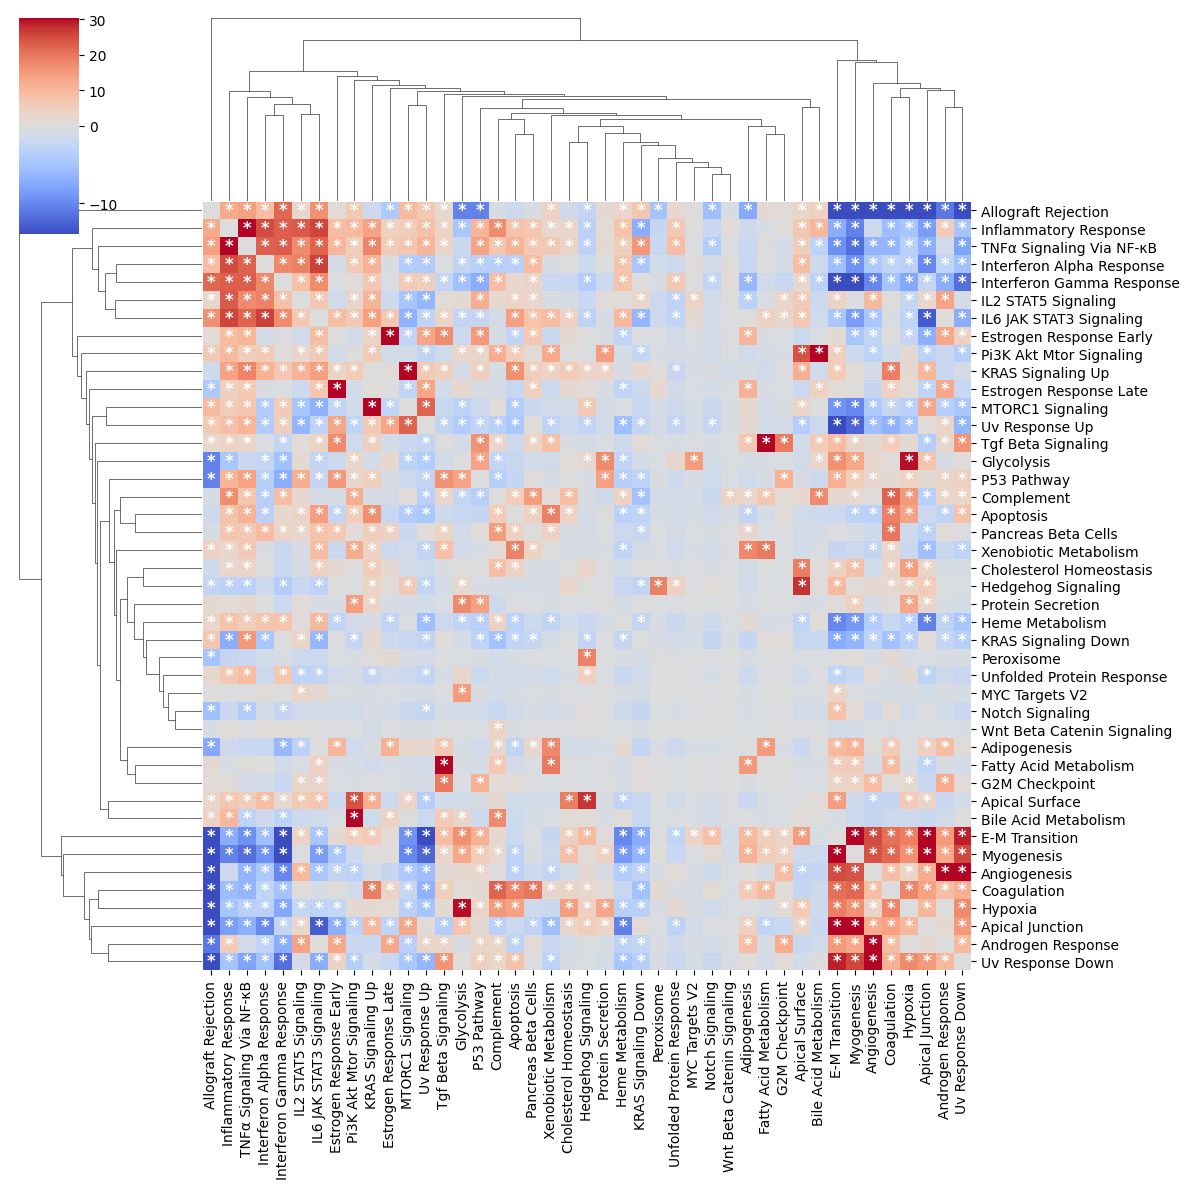

In [33]:
import pandas as pd
import re

all_circuits = pd.read_csv(
    '/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs.csv',
)
all_circuits['all_genes'] =  all_circuits['Interaction'].apply(lambda x: re.split('[+_&]', x))

# Load hallmark gene sets
def read_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                gene_sets[parts[0]] = set(parts[2:])
    return gene_sets

# Load hallmark data
hallmarks_path = '/home/lnemati/resources/msigdb_hallmarks/h.all.v2024.1.Hs.symbols.gmt'
hallmarks = read_gmt(hallmarks_path)

# Generate readable labels
labels = [label.replace('HALLMARK_', '').replace('_', ' ').title() for label in hallmarks.keys()]

# Mapping for special formatting
replace = {
    'Myc': 'MYC',
    'Kras': 'KRAS',
    'Il2': 'IL2',
    'Stat5': 'STAT5',
    'Il6': 'IL6',
    'Jak': 'JAK',
    'Stat3': 'STAT3',
    'P53': 'P53',
    'Tnfa': 'TNFα',
    'Nfkb': 'NF-κB',
    'Mtorc1': 'MTORC1',
    ' Dn': ' Down',
    'Epithelial Mesenchymal Transition': 'E-M Transition'
}

# Apply replacements to labels
for str1, str2 in replace.items():
    labels = [label.replace(str1, str2) for label in labels]

# Map original hallmark names to cleaned labels
hallmark_name_map = dict(zip(hallmarks.keys(), labels))

# Identify overlapping hallmark names (original form)
def find_matching_hallmarks(gene_list, hallmark_sets):
    return [name for name, genes in hallmark_sets.items() if set(gene_list) & genes]

# Assign original hallmark names per row
all_circuits['hallmarks'] = all_circuits['all_genes'].apply(lambda genes: find_matching_hallmarks(genes, hallmarks))

# Convert to readable labels
all_circuits['hallmarks'] = all_circuits['hallmarks'].apply(
    lambda hlist: [hallmark_name_map[h] for h in hlist]
)

# Extract all hallmark
all_hallmarks = sorted(set(sum(all_circuits['hallmarks'], [])))

# Add True/False column for each readable hallmark label
for label in all_hallmarks:
    all_circuits[label] = all_circuits['hallmarks'].apply(lambda x: label in x)

mask = all_circuits['Type'].isin(['3_clique', '4_clique'])

cliques = all_circuits[mask]
non_cliques = all_circuits[~mask]

cliques_hm = cliques.iloc[:, 5:]
non_cliques_hm = non_cliques.iloc[:, 5:]

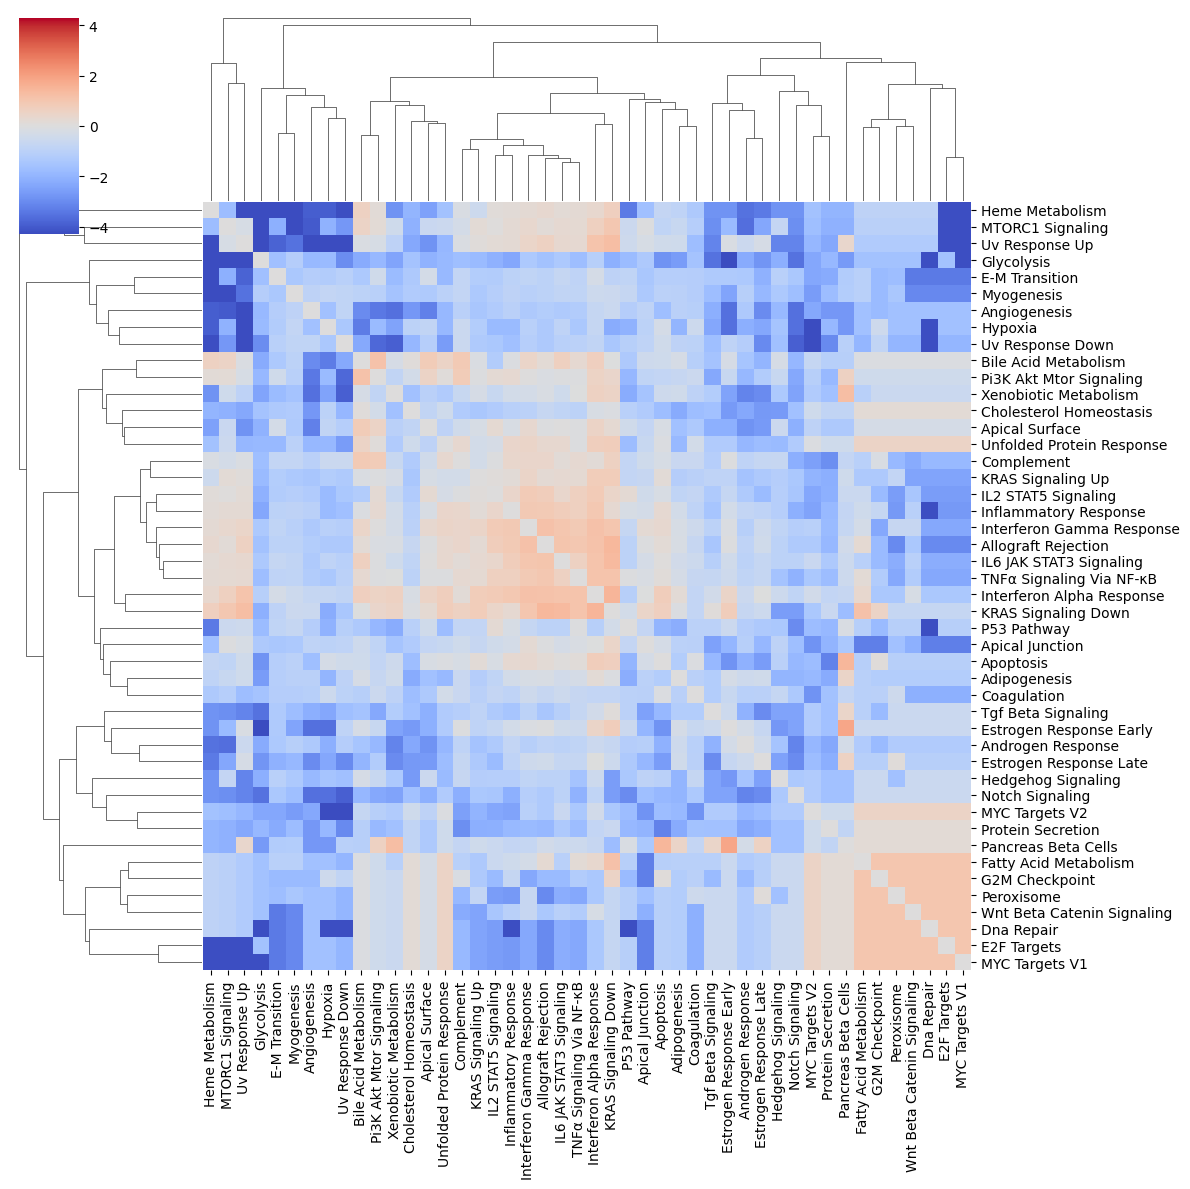

In [41]:
# --- Convert to numpy ---
C = cliques_hm.astype(int).values
NC = non_cliques_hm.astype(int).values
cols = cliques_hm.columns
n = len(cols)

# --- Co-occurrence counts ---
# a = both present in cliques
a = C.T @ C

# b = both present in non-cliques
b = NC.T @ NC

# c = present in i but not j (cliques vs non-cliques context handled via marginals)
# compute marginals
c1 = C.sum(axis=0)  # per hallmark in cliques
c2 = NC.sum(axis=0) # per hallmark in non-cliques

# --- Build contingency tables for each pair ---
# For each (i,j):
#        clique   non-clique
# both     a         b
# not      ?         ?

# total pairs = number of rows
nC = C.shape[0]
nNC = NC.shape[0]

# expected "not both"
not_a = nC - a
not_b = nNC - b

# --- Log Odds Ratio ---
eps = 0.5  # Haldane-Anscombe correction (prevents inf)

lor = np.log(
    (a + eps) * (not_b + eps) /
    ((b + eps) * (not_a + eps))
)

lor = pd.DataFrame(lor, index=cols, columns=cols)

lor_values = lor.values.copy()  # <-- key fix
np.fill_diagonal(lor_values, 0)
lor = pd.DataFrame(lor_values, index=cols, columns=cols)

# --- Plot ---
from matplotlib.colors import TwoSlopeNorm

# symmetric scaling (important for interpretability)
abs_max = np.percentile(np.abs(lor.values), 99)

norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

g = sns.clustermap(
    lor,
    cmap='coolwarm',
    norm=norm,
    figsize=(12, 12)
)

#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/hallmarks_LOR_heatmap.pdf',
#            dpi=300, bbox_inches='tight')
#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/hallmarks_LOR_heatmap.png',
#            dpi=300, bbox_inches='tight')

plt.show()

In [15]:
# --- Imports ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import false_discovery_control
from tqdm import tqdm

# --- Prepare data ---
hmdf = cliques.iloc[:, 5:]
X = hmdf.astype(int)
cols = X.columns
X_np = X.values

# --- Observed co-occurrence ---
observed = X_np.T @ X_np

# --- Permutations ---
N_PERMS = 1000
n_cols = X_np.shape[1]

perm_counts = np.zeros((N_PERMS, n_cols, n_cols), dtype=np.float32)

for i in tqdm(range(N_PERMS)):
    # shuffle each column independently
    X_perm = np.vstack([
        np.random.permutation(X_np[:, j])
        for j in range(n_cols)
    ]).T
    
    perm_counts[i] = X_perm.T @ X_perm

# --- Null distribution stats ---
perm_mean = perm_counts.mean(axis=0)
perm_std = perm_counts.std(axis=0, ddof=1)

# --- Effect size: log(observed / expected) ---
#eps = 1e-9  # small pseudocount
#log_ratio = np.log((observed + eps) / (perm_mean + eps))
#log_ratio = pd.DataFrame(log_ratio, index=cols, columns=cols)

z = (observed - perm_mean) / perm_std
z = pd.DataFrame(z, index=cols, columns=cols)
z = z.fillna(0)

# --- Empirical p-values (right-tailed: enrichment) ---
# absolute deviation from null mean
obs_dev = np.abs(observed - perm_mean)
perm_dev = np.abs(perm_counts - perm_mean)

pvals = (np.sum(perm_dev >= obs_dev, axis=0) + 1) / (N_PERMS + 1)
pvals = pd.DataFrame(pvals, index=cols, columns=cols)

# Multiple hypothesis correction
tri_upper = np.triu_indices_from(pvals, k=1)
pvals_upper = pvals.values[tri_upper]
pvals_upper_adj = false_discovery_control(pvals_upper)
pvals_adj = np.ones_like(pvals.values) # init
pvals_adj[tri_upper] = pvals_upper_adj # fill
pvals_adj[(tri_upper[1], tri_upper[0])] = pvals_upper_adj # mirror lower triangle
pvals_adj = pd.DataFrame(pvals_adj, index=cols, columns=cols) # convert to df

significant = pvals_adj < 0.05

100%|██████████| 1000/1000 [00:08<00:00, 116.84it/s]
/var/tmp/pbs.434089.pbs01/ipykernel_7068/1422539136.py:42: RuntimeWarning: invalid value encountered in divide
  z = (observed - perm_mean) / perm_std
